In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
#Load data
INPUT_PATH = "../data/processed/arxiv_with_readability.csv"
df = pd.read_csv(INPUT_PATH)

print(df.head())

                            paper_id  \
0  http://arxiv.org/abs/1901.00064v3   
1  http://arxiv.org/abs/1901.00063v2   
2  http://arxiv.org/abs/1901.00062v3   
3  http://arxiv.org/abs/1901.00059v2   
4  http://arxiv.org/abs/1901.00056v2   

                                               title             field  \
0  Impossibility and Uncertainty Theorems in AI V...  computer_science   
1  Extreme Relative Pose Estimation for RGB-D Sca...  computer_science   
2             Deep Frame Prediction for Video Coding  computer_science   
3  Determining Principal Component Cardinality th...  computer_science   
4  Entity Synonym Discovery via Multipiece Bilate...  computer_science   

                                            abstract  \
0  Utility functions or their equivalents (value ...   
1  Estimating the relative rigid pose between two...   
2  We propose a novel frame prediction method usi...   
3  PCA (Principal Component Analysis) and its var...   
4  Being able to automatically dis

In [ ]:
#Since citations_count column is skewed, we apply log(x+1) transform
df["log_citations"] = np.log1p(df["citation_count"])  # log(citations + 1)

In [4]:
readability_metrics = ["flesch_reading_ease", "flesch_kincaid_grade", "gunning_fog", "smog_index"]
print("=== Spearman Correlation between Readability Metrics and Citations ===")
for metric in readability_metrics:
    rho, pval = spearmanr(df[metric], df["citation_count"])
    print(f"{metric}: Spearman rho={rho:.3f}, p={pval:.3g}")

=== Spearman Correlation between Readability Metrics and Citations ===
flesch_reading_ease: Spearman rho=-0.153, p=2.44e-13
flesch_kincaid_grade: Spearman rho=0.114, p=5.15e-08
gunning_fog: Spearman rho=0.082, p=9.75e-05
smog_index: Spearman rho=0.094, p=7.02e-06


In [ ]:
# Pearson correlation (readability vs log citations)
print("=== Pearson Correlation ===")
for metric in readability_metrics:
    r, pval = pearsonr(df[metric], df["log_citations"])
    print(f"{metric}: Pearson r={r:.3f}, p={pval:.3g}")

=== Pearson Correlation ===
flesch_reading_ease: Pearson r=-0.157, p=5.79e-14
flesch_kincaid_grade: Pearson r=0.094, p=6.85e-06
gunning_fog: Pearson r=0.066, p=0.00154
smog_index: Pearson r=0.080, p=0.000124


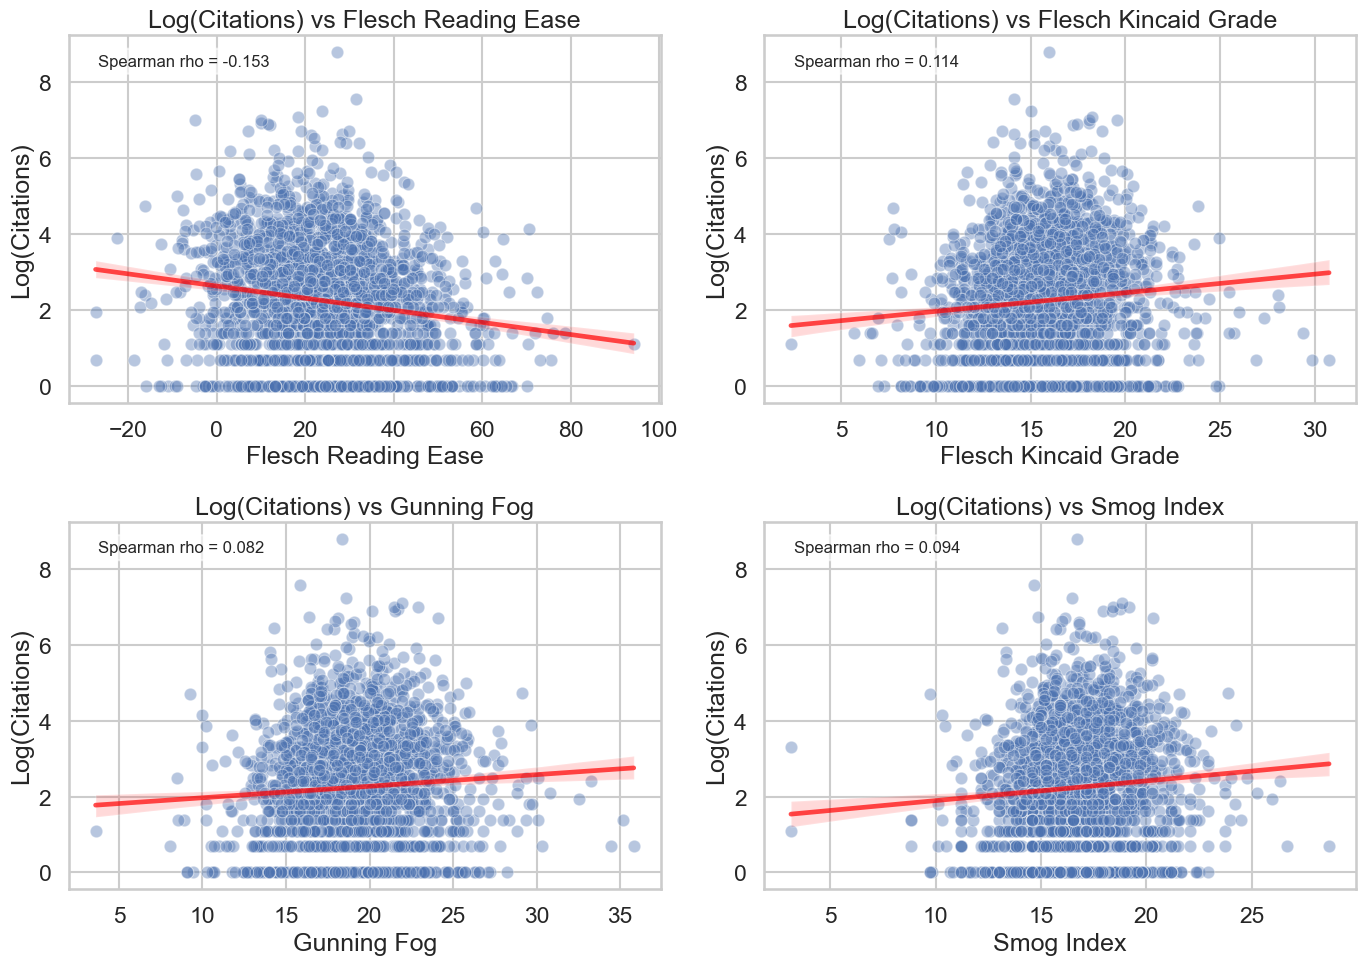

In [ ]:
#scatter plots of log transformed citation count vs readability metrics
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(readability_metrics):
    sns.scatterplot(
        x=df[metric],
        y=df["log_citations"],
        alpha=0.4,
        ax=axes[i]
    )
    # Add linear trend line
    sns.regplot(
        x=df[metric],
        y=df["log_citations"],
        scatter=False,
        ax=axes[i],
        line_kws={"color": "red", "alpha": 0.7}
    )
    
    # Compute Spearman correlation
    rho, pval = spearmanr(df[metric], df["log_citations"])
    
    # Add rho value as text on the plot
    axes[i].text(
        0.05, 0.95,
        f"Spearman rho = {rho:.3f}",
        transform=axes[i].transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
    )
    
    axes[i].set_title(f"Log(Citations) vs {metric.replace('_', ' ').title()}")
    axes[i].set_xlabel(metric.replace('_', ' ').title())
    axes[i].set_ylabel("Log(Citations)")

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_35628\1777982502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="citation_quartile", y=metric, data=df, palette="coolwarm")


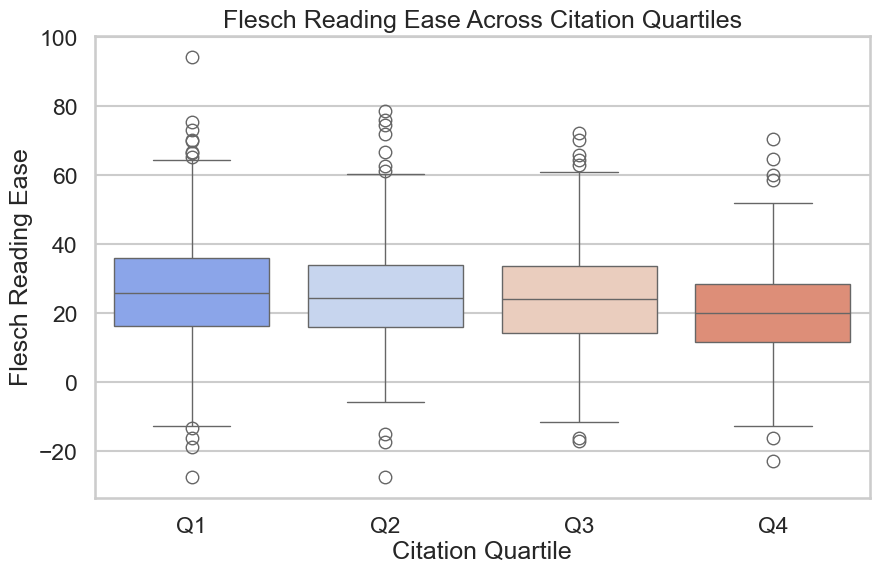

C:\Users\user\AppData\Local\Temp\ipykernel_35628\1777982502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="citation_quartile", y=metric, data=df, palette="coolwarm")


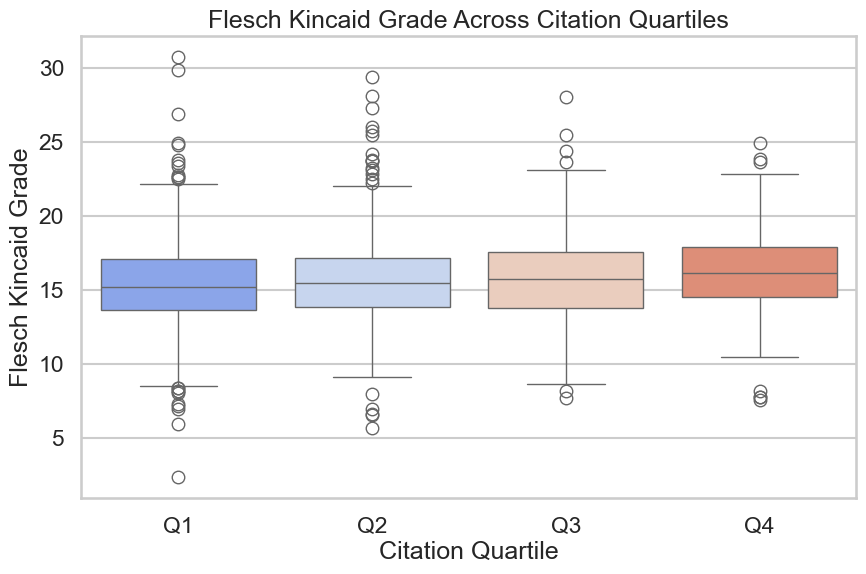

C:\Users\user\AppData\Local\Temp\ipykernel_35628\1777982502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="citation_quartile", y=metric, data=df, palette="coolwarm")


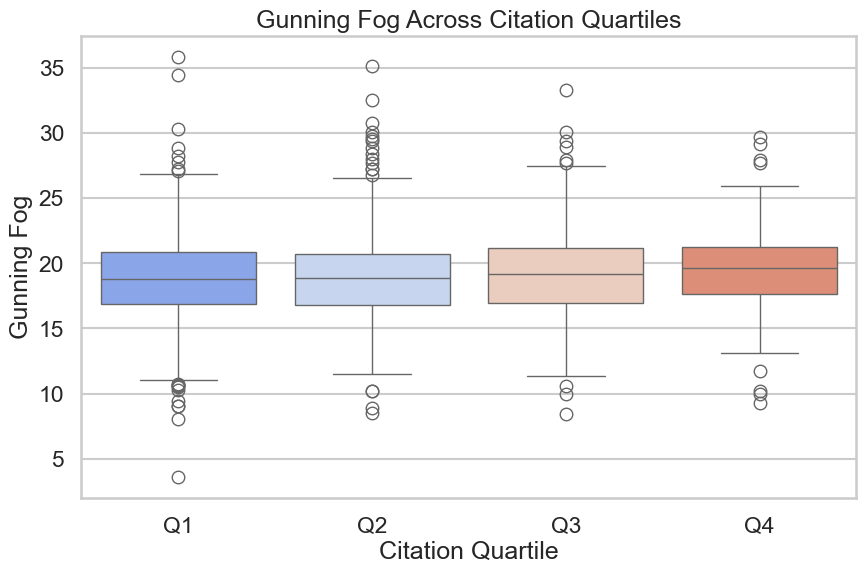

C:\Users\user\AppData\Local\Temp\ipykernel_35628\1777982502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="citation_quartile", y=metric, data=df, palette="coolwarm")


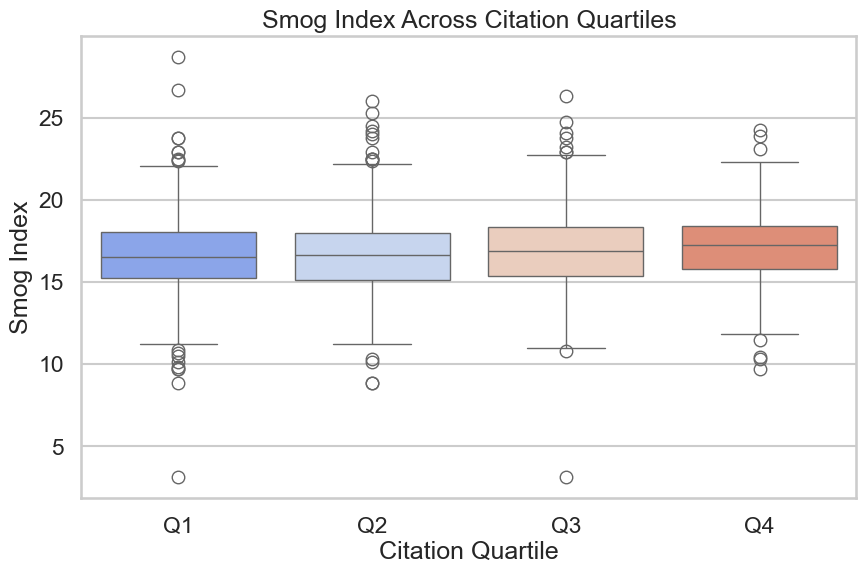

In [8]:
#Boxplots of readability across citation quartiles
df["citation_quartile"] = pd.qcut(df["citation_count"], 4, labels=["Q1","Q2","Q3","Q4"])

for metric in readability_metrics:
    plt.figure()
    sns.boxplot(x="citation_quartile", y=metric, data=df, palette="coolwarm")
    plt.xlabel("Citation Quartile")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} Across Citation Quartiles")
    plt.show()

In [ ]:
#regression analysis (all metrics vs log citations)
X = df[readability_metrics]
X = sm.add_constant(X)  # add intercept
y = df["log_citations"]

model = sm.OLS(y, X).fit()
print(model.summary())